# Data Visualization Notebook

In [1]:
%load_ext autoreload
%autoreload 2

import physical_ai_av
import numpy as np
import mediapy as mp
from physical_ai_av.utils import tf
import matplotlib.pyplot as plt

In [2]:
# Initialize interface
avdi = physical_ai_av.PhysicalAIAVDatasetInterface()

In [34]:
clip_id = "99a9ff74-d5cb-4f58-8364-bdd32e611c4f"
camera = avdi.features.CAMERA.CAMERA_FRONT_TELE_30FOV
prediction_timestamp_us = 1_100_000


# Get video data
video = avdi.get_clip_feature(clip_id, feature=camera, maybe_stream=True)

frame_timestamps_us = prediction_timestamp_us + 100_000 * np.arange(-10, 1)
frames, actual_timestamps_us = video.decode_images_from_timestamps(frame_timestamps_us)

# Get calibration data
extrinsics = avdi.get_clip_feature(
    clip_id, feature=avdi.features.CALIBRATION.SENSOR_EXTRINSICS, maybe_stream=True
)
intrinsics = avdi.get_clip_feature(
    clip_id, feature=avdi.features.CALIBRATION.CAMERA_INTRINSICS, maybe_stream=True
)
dimensions = avdi.get_clip_feature(
    clip_id, feature=avdi.features.CALIBRATION.VEHICLE_DIMENSIONS, maybe_stream=True
)

# Get egomotion data
egomotion = avdi.get_clip_feature(clip_id, maybe_stream=True, feature=avdi.features.LABELS.EGOMOTION)

### egomotionをロングテールケースで差し替え

In [ ]:
###　差し替える場合のみこのセルを実行してください
import pandas as pd
import numpy as np
from scipy.spatial.transform import Rotation, RigidTransform
from physical_ai_av.utils.interpolation import Interpolator

df = pd.read_csv("~/work/physicsnemo/physicsnemo/artifacts_physicsnemo/ego_history_full_low_mu_high_speed.csv")
df = df.sort_values("timestamp_us").drop_duplicates("timestamp_us")

pose = RigidTransform.from_components(
    rotation=Rotation.from_quat(df[["qx", "qy", "qz", "qw"]].to_numpy(float)),
    translation=df[["x", "y", "z"]].to_numpy(float),
)

values = EgomotionStateType(
    pose=pose,
    velocity=df[["vx", "vy", "vz"]].to_numpy(float),
    acceleration=df[["ax", "ay", "az"]].to_numpy(float),
    curvature=df[["curvature"]].to_numpy(float),
)

egomotion = Interpolator(
    timestamps=df["timestamp_us"].to_numpy(np.int64) ,
    values=values,
)

In [31]:
# Display video
mp.show_video(frames, fps=10, width=512)

This browser does not support the video tag.


# Demo of using TF Tree

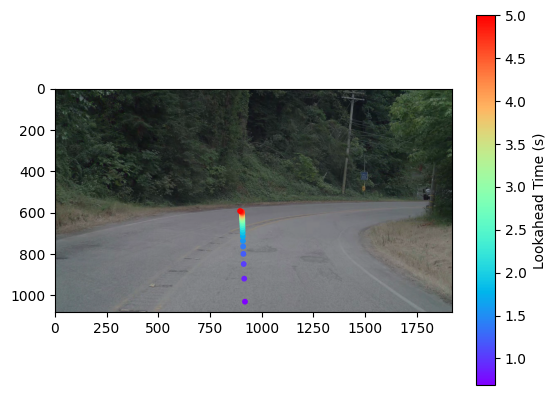

<Figure size 640x480 with 0 Axes>

In [75]:
# First, set up the transform tree
tf_tree = tf.TransformTree()
tf_tree.add_transform("anchor", "ego", egomotion)
for sensor_id, sensor_pose in extrinsics.sensor_poses.items():
    tf_tree.add_transform("ego", sensor_id, sensor_pose)

# Now, let's get the egomotion data in the frame of the camera at the last frame timestamp
frame_time = actual_timestamps_us[-1]
anchor_to_camera_frame = tf_tree.lookup_transform(
    tf.FrameInfo(camera, frame_time), tf.FrameInfo("anchor")
)

query_times = np.linspace(frame_time, frame_time + 5_000_000, 30)
egomotion_in_camera_frame = egomotion(query_times).transform(
    anchor_to_camera_frame.tf_target_source
)

egomotion_pose_in_camera_image = intrinsics.camera_models[camera].ray2pixel(
    egomotion_in_camera_frame.pose.translation
)
# don't draw out of bounds pixels
egomotion_pose_in_camera_image = np.where(
    intrinsics.camera_models[camera].is_out_of_bounds(egomotion_pose_in_camera_image)[..., None],
    np.nan,
    egomotion_pose_in_camera_image,
)

# Plot the image along with the transformed egomotion
fig, ax = plt.subplots(1)
ax.imshow(frames[-1])
h = ax.scatter(
    egomotion_pose_in_camera_image[:, 0],
    egomotion_pose_in_camera_image[:, 1],
    c=(query_times - frame_time) / 1e6,
    s=10,
    cmap="rainbow",
)
plt.colorbar(h, label="Lookahead Time (s)", ax=ax)
plt.show()
plt.tight_layout()

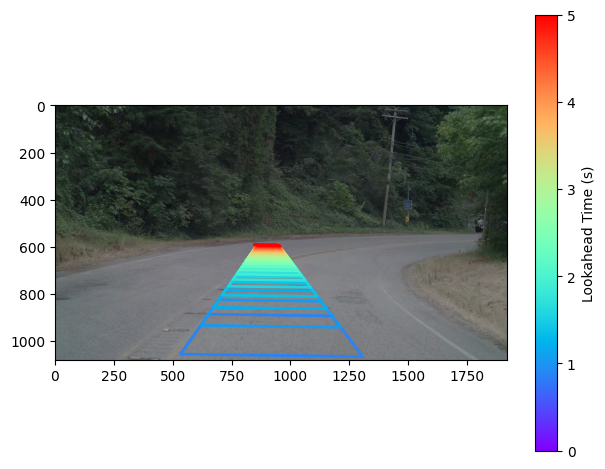

In [46]:
# Use the vehicle dimensions to plot the bounding box
bbox_corners_xyz_ego_frame = np.array(
    [
        [dimensions.length / 2, dimensions.width / 2, 0],
        [dimensions.length / 2, -dimensions.width / 2, 0],
        [-dimensions.length / 2, -dimensions.width / 2, 0],
        [-dimensions.length / 2, dimensions.width / 2, 0],
        [dimensions.length / 2, dimensions.width / 2, 0],
    ]
)
bbox_corners_xyz_ego_frame[..., 0] -= dimensions.rear_axle_to_bbox_center
bbox_corners_xyz_anchor_frame = egomotion(query_times).pose.apply(
    bbox_corners_xyz_ego_frame[:, None, :]
)
bbox_corners_xyz_camera_frame = anchor_to_camera_frame.tf_target_source.apply(
    bbox_corners_xyz_anchor_frame.reshape(-1, 3)
).reshape(5, -1, 3)
bbox_corners_uv_camera_image = intrinsics.camera_models[camera].ray2pixel(
    bbox_corners_xyz_camera_frame
)

# don't draw out of bounds bounding boxes
bbox_corners_uv_camera_image = np.where(
    intrinsics.camera_models[camera]
    .is_out_of_bounds(bbox_corners_uv_camera_image)
    .any(axis=0)[None, :, None],
    np.nan,
    bbox_corners_uv_camera_image,
)


# Plot the image along with the transformed egomotion
fig, ax = plt.subplots(1)
ax.imshow(frames[-1])

# Create a colormap and normalizer for the lookahead time
cmap = plt.cm.rainbow
norm = plt.cm.colors.Normalize(vmin=0, vmax=5)

# Plot each bounding box with color scaled by the lookahead time
for i in range(bbox_corners_uv_camera_image.shape[1]):
    lookahead_time = (query_times[i] - frame_time) / 1e6
    color = cmap(norm(lookahead_time))
    ax.plot(
        bbox_corners_uv_camera_image[:, i, 0],
        bbox_corners_uv_camera_image[:, i, 1],
        color=color,
        linewidth=2,
    )

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, label="Lookahead Time (s)", ax=ax)
plt.tight_layout()
plt.show()